In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Dynamically Load Data
# This ensures it works regardless of where it is launched from, as long as the relative path is maintained.

project_root = Path().resolve().parent
data_path = project_root / 'data' / 'processed' / 'mcphases_cycle_syncing.csv'
df = pd.read_csv(data_path)

In [4]:
# 2. Encode Categorical Features
# Ordinal encoding preserves the progressive nature of the phases and fatigue
phase_map = {'Menstrual': 0, 'Follicular': 1, 'Fertility': 2, 'Luteal': 3}
fatigue_map = {'Not at all': 0, 'Very Low/Little': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very High': 5}

df['phase_encoded'] = df['phase'].map(phase_map)
df['fatigue_encoded'] = df['fatigue'].map(fatigue_map)

# Catch any unmapped edge cases with the median
df['phase_encoded'] = df['phase_encoded'].fillna(df['phase_encoded'].median())
df['fatigue_encoded'] = df['fatigue_encoded'].fillna(df['fatigue_encoded'].median())

In [5]:
# 3. Define Features and Target
features = [
    'phase_encoded', 'age', 'estrogen', 'pdg', 'lh', 
    'resting_heart_rate', 'temperature_celsius', 
    'overall_score', 'stress_score', 'fatigue_encoded'
]

X = df[features]
y = df['exercise_target']

In [6]:
# 4. Train/Test Split
# stratify=y guarantees the same ratio of 'High'/'Low' intensities in both train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# 5. Train Random Forest
# class_weight='balanced' forces the model to pay attention to minority classes (like 'Very High' intensity)
rf_model = RandomForestClassifier(
    n_estimators=200, 
    min_samples_split=10, 
    max_depth=15,
    random_state=42, 
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


--- Classification Report ---

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.46      0.46      0.46       135
           2       0.51      0.52      0.51       231
           3       0.48      0.53      0.51       219
           4       0.33      0.20      0.25        69
           5       0.08      0.09      0.09        11

    accuracy                           0.47       666
   macro avg       0.31      0.30      0.30       666
weighted avg       0.47      0.47      0.47       666



c:\BioAligned-Fit\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\BioAligned-Fit\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\BioAligned-Fit\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


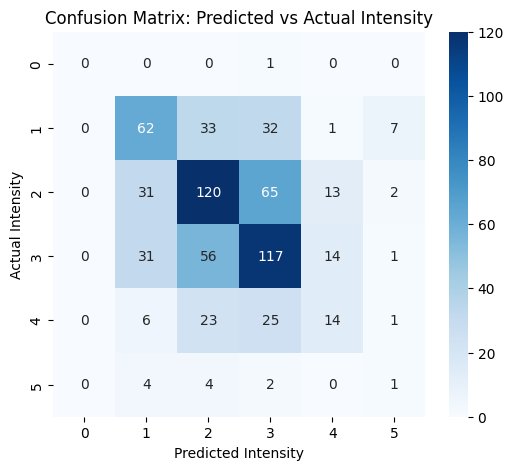

In [8]:
# 6. Evaluation
y_pred = rf_model.predict(X_test)
print("--- Classification Report ---\n")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual Intensity')
plt.ylabel('Actual Intensity')
plt.xlabel('Predicted Intensity')
plt.show()

The Problem: The model struggles with the "Very High" class due to extreme data imbalance (only 11 samples out of 666). Furthermore, a standard classifier penalizes a "near-miss" (predicting 2 instead of 3) exactly the same as a complete failure (predicting 0 instead of 5), ignoring the biological ordinality of the data.

The Solution: To solve class sparsity, group the target variable into three robust buckets: Light (0), Moderate (1), and High (2). To solve the ordinality issue, replace the Classifier with a RandomForestRegressor, forcing the model to understand that the intensities exist on a sliding mathematical scale.

In [14]:
from sklearn.ensemble import RandomForestRegressor

In [9]:
# 2. Encode Categorical Features
phase_map = {'Menstrual': 0, 'Follicular': 1, 'Fertility': 2, 'Luteal': 3}
fatigue_map = {'Not at all': 0, 'Very Low/Little': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very High': 5}

df['phase_encoded'] = df['phase'].map(phase_map).fillna(df['phase'].map(phase_map).median())
df['fatigue_encoded'] = df['fatigue'].map(fatigue_map).fillna(df['fatigue'].map(fatigue_map).median())

In [10]:
# 3. Bin the Target Variables (The Pragmatic Fix)
# 0-1 -> 0 (Light) | 2-3 -> 1 (Moderate) | 4-5 -> 2 (High)
def bin_target(val):
    if val in [0, 1]: return 0
    elif val in [2, 3]: return 1
    elif val in [4, 5]: return 2
    return 0

df['binned_target'] = df['exercise_target'].apply(bin_target)

In [11]:
# 4. Define Features and Target
features = [
    'phase_encoded', 'age', 'estrogen', 'pdg', 'lh', 
    'resting_heart_rate', 'temperature_celsius', 
    'overall_score', 'stress_score', 'fatigue_encoded'
]

X = df[features]
y = df['binned_target']

In [12]:
# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# 6. Train Random Forest CLASSIFIER (The Balanced Binned Fix)
rf_model = RandomForestClassifier(
    n_estimators=200, 
    min_samples_split=10, 
    max_depth=15,
    random_state=42,
    class_weight='balanced' # Forces the model to care about Light & High days
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# 7. Predict directly (no rounding needed for Classifiers)
y_pred = rf_model.predict(X_test)

--- Classification Report (Balanced & Binned) ---

              precision    recall  f1-score   support

   Light (0)       0.46      0.36      0.40       136
Moderate (1)       0.72      0.86      0.78       449
    High (2)       0.20      0.07      0.11        81

    accuracy                           0.66       666
   macro avg       0.46      0.43      0.43       666
weighted avg       0.61      0.66      0.62       666



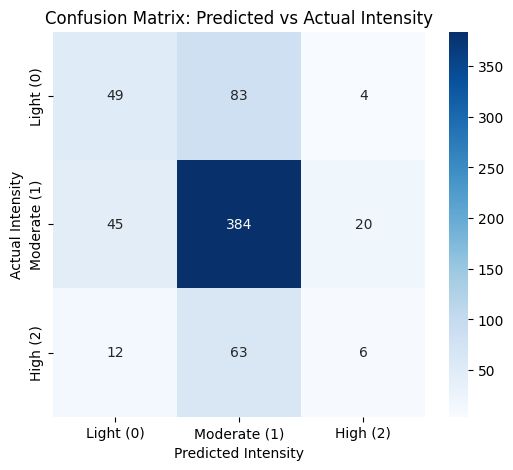

['C:\\BioAligned-Fit\\models\\rf_activity_model.pkl']

In [22]:
# 8. Evaluation
target_names = ['Light (0)', 'Moderate (1)', 'High (2)']
print("--- Classification Report (Balanced & Binned) ---\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Predicted vs Actual Intensity')
plt.ylabel('Actual Intensity')
plt.xlabel('Predicted Intensity')
plt.show()

# Save Model
joblib.dump(rf_model, model_path)

In [21]:
import joblib
from pathlib import Path

# Define path dynamically
project_root = Path().resolve().parent
model_dir = project_root / 'models'
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'rf_activity_model.pkl'

# Save Model
joblib.dump(rf_model, model_path)
print(f"Success! Model saved to {model_path}")

Success! Model saved to C:\BioAligned-Fit\models\rf_activity_model.pkl
